### 🛠️ Project: Steel Quality Anomaly & Factor Analysis
(부제: 슬라브 크랙 발생 영향 인자 분석 시뮬레이션)

실제 슬라브 크랙 데이터 대신, 캐글에서 가장 유사한 성격의 데이터셋을 활용해 분석 파이프라인을 구축해봅시다.

#### 🛠️ Step 1: 환경 설정 및 데이터 로드
Steel Plate Defects 데이터를 사용한다고 가정하고 코드를 짜보자.

In [9]:
df.head()

,X_Minimum,X_Maximum,Y_Minimum,Y_Maximum,Pixels_Areas,X_Perimeter,Y_Perimeter,Sum_of_Luminosity,Minimum_of_Luminosity,Maximum_of_Luminosity,...,Orientation_Index,Luminosity_Index,SigmoidOfAreas,Pastry,Z_Scratch,K_Scatch,Stains,Dirtiness,Bumps,Other_Faults
0,42,50,270900,270944,267,17,44,24220,76,108,...,0.8182,-0.2913,0.5822,1,0,0,0,0,0,0
1,645,651,2538079,2538108,108,10,30,11397,84,123,...,0.7931,-0.1756,0.2984,1,0,0,0,0,0,0
2,829,835,1553913,1553931,71,8,19,7972,99,125,...,0.6667,-0.1228,0.2150,1,0,0,0,0,0,0
3,853,860,369370,369415,176,13,45,18996,99,126,...,0.8444,-0.1568,0.5212,1,0,0,0,0,0,0
4,1289,1306,498078,498335,2409,60,260,246930,37,126,...,0.9338,-0.1992,1.0000,1,0,0,0,0,0,0


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# 분석 도구 (영향 인자 분석용)
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
import shap  # 설명 가능한 AI (강력 추천!)

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8') # 깔끔한 그래프 스타일

# 데이터 로드 (Kaggle에서 받은 csv 파일 경로)
df = pd.read_csv('faults.csv')

# 결함 종류 중 'Other_Faults'를 제외하고 'Bumps'나 'Dirtiness' 등을 
# 슬라브의 'Crack'이라 가정하고 분석을 진행해 봅시다.
print(df.columns)

Index(['X_Minimum', 'X_Maximum', 'Y_Minimum', 'Y_Maximum', 'Pixels_Areas',
       'X_Perimeter', 'Y_Perimeter', 'Sum_of_Luminosity',
       'Minimum_of_Luminosity', 'Maximum_of_Luminosity', 'Length_of_Conveyer',
       'TypeOfSteel_A300', 'TypeOfSteel_A400', 'Steel_Plate_Thickness',
       'Edges_Index', 'Empty_Index', 'Square_Index', 'Outside_X_Index',
       'Edges_X_Index', 'Edges_Y_Index', 'Outside_Global_Index', 'LogOfAreas',
       'Log_X_Index', 'Log_Y_Index', 'Orientation_Index', 'Luminosity_Index',
       'SigmoidOfAreas', 'Pastry', 'Z_Scratch', 'K_Scatch', 'Stains',
       'Dirtiness', 'Bumps', 'Other_Faults'],
      dtype='object')


In [4]:
import sklearn
import shap
print(f"Scikit-learn 버전: {sklearn.__version__}")
print(f"SHAP 버전: {shap.__version__}")

Scikit-learn 버전: 1.7.2
SHAP 버전: 0.49.1


#### 📊 Step 2: EDA - "무엇이 크랙(결함)을 만드는가?"

데이터를 불러왔다면, 가장 먼저 각 변수들이 결함과 어떤 상관관계를 갖는지 시각화해야 합니다. 선배님이 궁금해하시는 '영향 인자'의 실마리를 찾는 과정입니다.

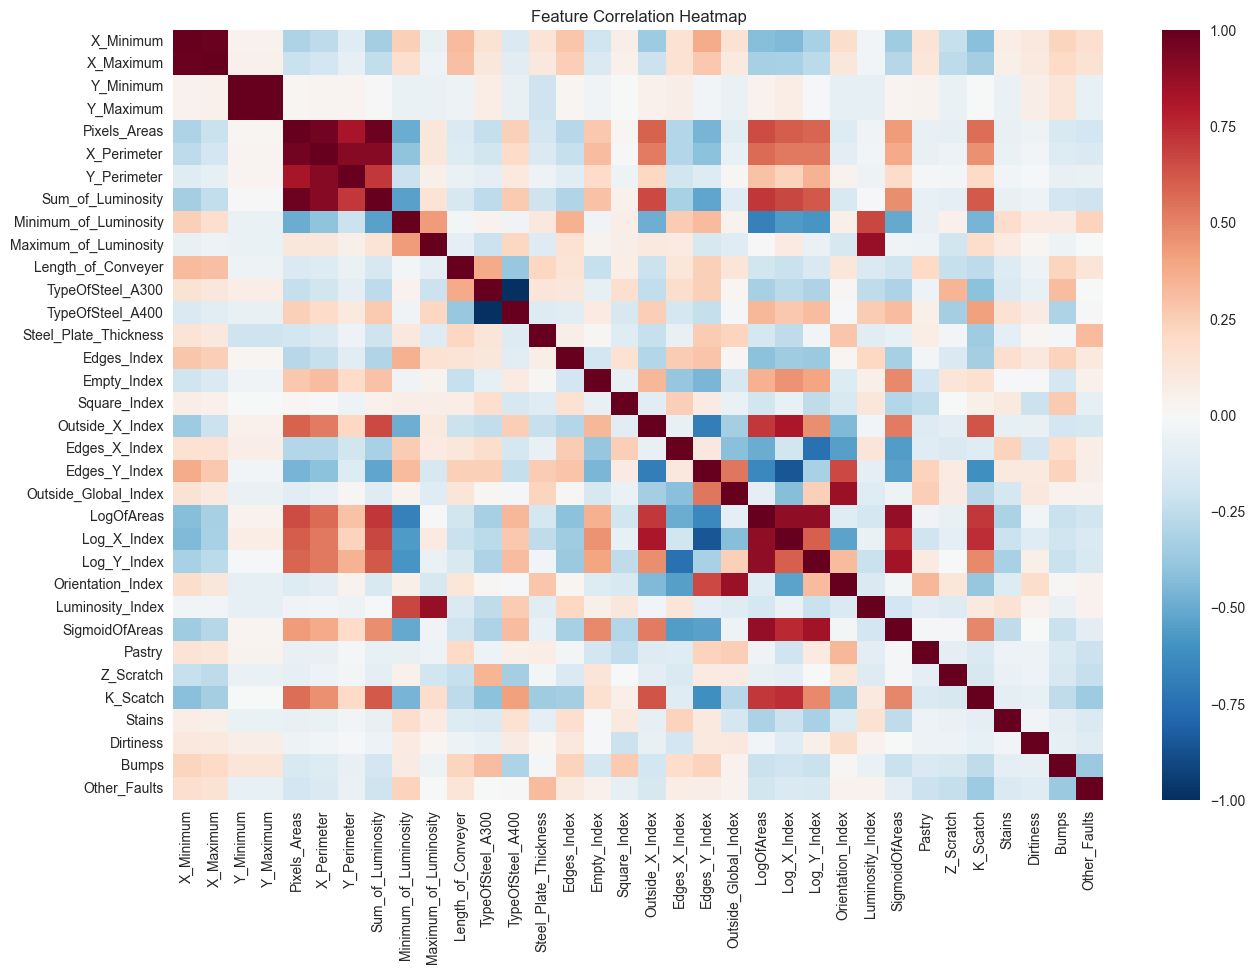

결함과 상관관계가 높은 상위 인자:
 Bumps                 1.000000
TypeOfSteel_A300      0.306385
Square_Index          0.261385
Edges_Index           0.232000
Edges_Y_Index         0.229231
Length_of_Conveyer    0.225504
X_Minimum             0.221296
X_Maximum             0.201704
Edges_X_Index         0.185481
Y_Minimum             0.126121
Name: Bumps, dtype: float64


In [7]:
# 상관관계 히트맵 (Target 변수와 인자들 간의 관계)
plt.figure(figsize=(15, 10))
sns.heatmap(df.corr(), annot=False, cmap='RdBu_r')
plt.title('Feature Correlation Heatmap')
plt.show()

# 특정 결함(예: Bumps)과 상관관계가 높은 Top 10 인자 확인
target_corr = df.corr()['Bumps'].sort_values(ascending=False)
print("결함과 상관관계가 높은 상위 인자:\n", target_corr.head(10))

📊 EDA 결과 해석: "범인의 실마리"

지금 Bumps(돌출 결함)를 기준으로 상관계수를 뽑으셨는데, 이걸 슬라브 크랙이라 가정하고 해석해 보면 이렇습니다.

강종의 영향 (TypeOfSteel_A300: 0.306):

특정 강종(A300)에서 결함이 훨씬 자주 발생하고 있습니다. 현장에서도 "특정 성분의 강종이 크랙에 취약하다"는 가설을 세울 수 있는 근거가 됩니다.

기하학적 지표 (Square_Index, Edges_Index 등):

정사각형에 가까운지, 가장자리의 특성이 어떤지가 결함과 관련이 깊습니다. 이는 연주 공정에서 몰드의 형상이나 냉각 균일성이 크랙에 미치는 영향과 일맥상통합니다.

설비 상태 (Length_of_Conveyer: 0.225):

컨베이어 길이라는 설비 변수가 순위에 올랐습니다. 실제 공정이라면 연주기 롤러 간격이나 인발 속도 같은 변수가 이 역할을 하겠죠.

⚠️ 주의점: 상관계수가 높다고 해서 반드시 원인인 것은 아닙니다. 단순히 같이 움직이는 것일 수도 있죠. 그래서 우리는 **Step 3 (Random Forest)** 를 통해 "진짜 인과관계에 기여하는 중요도"를 뽑아야 합니다.

#### 🧠 Step 3: Random Forest를 활용한 영향 인자 도출
이제 머신러닝 모델을 통해 변수의 중요도(Feature Importance)를 뽑아냅니다. 이 수치가 높을수록 "슬라브 크랙에 결정적인 영향을 미치는 범인"일 확률이 높습니다.

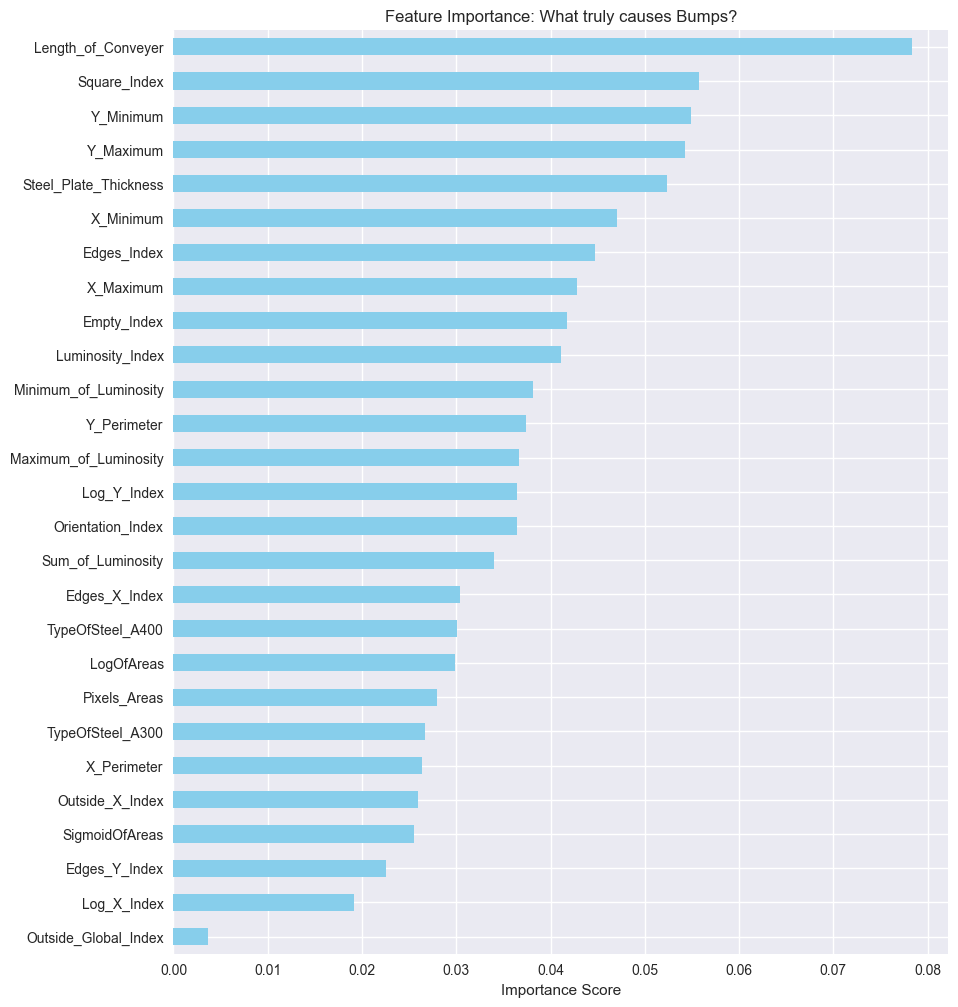

모델 정확도: 85.60%


In [8]:
# 1. 독립변수(X)와 종속변수(y) 분리
# 결함 관련 컬럼들을 제외한 모든 변수를 X로 사용합니다.
target_cols = ['Pastry', 'Z_Scratch', 'K_Scatch', 'Stains', 'Dirtiness', 'Bumps', 'Other_Faults']
X = df.drop(target_cols, axis=1)
y = df['Bumps'] 

# 2. 데이터 분할
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. 모델 학습 (영향 인자 분석을 위해 앙상블 모델 사용)
rf_model = RandomForestClassifier(n_estimators=200, random_state=42)
rf_model.fit(X_train, y_train)

# 4. 중요도 시각화
importances = pd.Series(rf_model.feature_importances_, index=X.columns)
plt.figure(figsize=(10, 12))
importances.sort_values().plot(kind='barh', color='skyblue')
plt.title('Feature Importance: What truly causes Bumps?')
plt.xlabel('Importance Score')
plt.show()

# 5. 정확도 확인 (참고용)
from sklearn.metrics import accuracy_score
print(f"모델 정확도: {accuracy_score(y_test, rf_model.predict(X_test)):.2%}")

상관관계 순위와 중요도 순위가 조금 다르게 나올 수 있습니다.

상관관계: 단순히 둘이 비슷하게 움직인다.

중요도: 모델이 결함을 맞추는 데 있어서 이 변수가 없으면 안 된다고 판단한다.

만약 중요도 상위권에 Square_Index나 특정 센서 데이터가 올라온다면, "상관 분석과 랜덤 포레스트 중요도를 교차 검증한 결과, 특정 형상 지수가 크랙 발생의 주요 지표로 판단됩니다" 라고 보고할 수 있습니다.